# 4 · Closing the loop on the estimator — a frequency-domain diagnosis

Notebook 3 left the estimator in an uncomfortable place. It tracked truth to
**0.104° RMS** standing still and **0.663° RMS** through a manoeuvre, comfortably
inside the 0.5°-ish budget — and the moment it was allowed to drive the
controller, the board fell over.

That should not follow. The same loop shrugs off **40 ms of pure actuation
delay**, twenty times the ICD's estimate. A sub-degree attitude error has no
business destabilising it. So the error is not too *big*; it must be the wrong
*shape*. This notebook is the measurement that says what shape, and the fix that
follows from it.

It is also, honestly, a notebook about being wrong four times in a row. Two of
the wrong turns produced plots that looked completely convincing, which is the
part worth keeping.

**On the data.** Everything here loads from `sim/out/experiments/`, produced by
`scripts/analyse_estimator_phase.py`. Every run is deterministic and seeded.

In [1]:
import json, sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA = REPO / "sim" / "out" / "experiments"
sys.path.insert(0, str(REPO))
if not (DATA / "estimator-phase.npz").exists():
    raise SystemExit("Run:  scripts/analyse_estimator_phase.py")

P = json.loads((DATA / "estimator-phase.json").read_text())
A = np.load(DATA / "estimator-phase.npz")
INK, AMBER, MINT, MUTED, RED = "#16232E", "#F2A24A", "#2AAE97", "#96A8B0", "#C2513B"
plt.rcParams.update({"figure.figsize": (10, 4), "axes.grid": True, "grid.alpha": 0.25})
WC = P["omega_crossover_rad_s"]
print(f"inner-loop crossover  w_c = {WC} rad/s   ({WC/6.283:.2f} Hz)")

inner-loop crossover  w_c = 12.0 rad/s   (1.91 Hz)


---
## Debugging story 0 — the estimator was never switched on

Before any analysis: the shuttle scenario had never actually fed the estimator.

Its stepping loop called the controller as `ctl(t, pitch, rate, wheel)` and
stopped there. The raw IMU is passed through two *optional* keyword arguments,
and omitting them does not raise — `RustController.__call__` simply leaves the
observation's `gyro_rad_s` and `accel_m_s2` at the zeros they were initialised
with. The filter then evaluates

$$\theta_{\text{accel}} = \operatorname{atan2}(0 - a_{\text{fwd}},\, -0)$$

every cycle, which in IEEE arithmetic is a perfectly finite $\pm\pi/2$ or $\pi$.
No NaN, no error, no warning. An estimator confidently reporting 180° of tilt.

The tell was that the shuttle's peak pitch came out at **exactly 20.163°** for
every value of $\tau$ from 1 s to 15 s. A tuning parameter that changes nothing
is not a tuning parameter — it means the thing you are tuning is not in the
path. The impulse scenario had always passed the IMU; the shuttle never did.

It was found by building a Python replica of the shipped filter, checking it
against the real one in shadow mode, and then *disagreeing with the real
scenario*. The replica was right.

In [2]:
v = P["replica_validation"]
print("Python replica vs the shipped Rust ComplementaryFilter, shadow mode:")
print(f"  max |difference| : {v['max_abs_deg']:.3e} deg over {v['samples']} samples")
print(f"  RMS difference   : {v['rms_deg']:.3e} deg")
print(f"  verdict          : {'faithful' if v['faithful'] else 'DIVERGED'}")
print("\nA replica is only worth having if it is checked. This one is a")
print("line-for-line port, and the check is what let it overrule the scenario.")

Python replica vs the shipped Rust ComplementaryFilter, shadow mode:
  max |difference| : 2.186e-05 deg over 10000 samples
  RMS difference   : 6.929e-06 deg
  verdict          : faithful

A replica is only worth having if it is checked. This one is a
line-for-line port, and the check is what let it overrule the scenario.


---
## Which path is actually guilty?

Switching the estimator on changes **two** things at once, and it is easy to
attribute the failure to the wrong one:

- the **P** term starts using fused pitch instead of truth, and
- the **D** term starts using the raw gyro instead of the truth rate.

D-term noise amplification is a classic destabiliser, so it is a live suspect.
Feeding the two paths independently costs four runs and settles it before any
spectral work.

In [3]:
rows = P["path_factorial"]["rows"]
print(f"{'P term':<10}{'D term':<9}{'falls over':>12}{'peak pitch':>13}{'est RMS':>10}")
for r in rows:
    print(f"{r['p_source']:<10}{r['d_source']:<9}{'YES' if r['struck'] else 'no':>12}"
          f"{r['peak_abs_pitch_deg']:12.2f}°{r['est_rms_deg']:9.3f}°")

t_t = next(r for r in rows if r["p_source"] == "truth" and r["d_source"] == "truth")
t_g = next(r for r in rows if r["p_source"] == "truth" and r["d_source"] == "gyro")
print(f"\nSwapping the D term alone moves peak pitch by "
      f"{abs(t_t['peak_abs_pitch_deg'] - t_g['peak_abs_pitch_deg']):.2f}° and changes no outcome.")
print("The D path is innocent. Everything that follows is about the P path.")

P term    D term     falls over   peak pitch   est RMS
truth     truth              no        7.63°    0.663°
truth     gyro               no        7.62°    0.663°
estimate  truth             YES       18.54°    2.719°
estimate  gyro              YES       18.52°    2.682°

Swapping the D term alone moves peak pitch by 0.01° and changes no outcome.
The D path is innocent. Everything that follows is about the P path.


---
## The maths: why $\hat\theta / \theta$ is not 1

A complementary filter high-passes the gyro and low-passes the accelerometer,
with the two weights summing to one at every frequency. With $\tau$ the
crossover time constant:

$$\hat\theta(s) \;=\; \underbrace{\frac{\tau s}{\tau s + 1}}_{\text{HP}}\,\theta_{\text{gyro}}(s)
\;+\; \underbrace{\frac{1}{\tau s + 1}}_{\text{LP}}\,\theta_{\text{accel}}(s),
\qquad \text{HP} + \text{LP} = 1 .$$

That identity is the whole appeal: if the gyro integrates to true pitch and the
accelerometer implies true pitch, the filter returns true pitch at *every*
frequency, with no lag. It is an all-pass by construction.

The gyro branch is essentially honest — integrated rate is true pitch plus a
slow bias term $b\tau$. The accelerometer branch is not. It measures **specific
force**, so under forward acceleration $a$ the tilt it implies is

$$\theta_{\text{accel}} \;=\; \operatorname{atan2}\!\left(f_x - \hat a_{\text{fwd}},\, -f_z\right)
\;\approx\; \theta \;+\; \underbrace{\frac{a - \hat a_{\text{fwd}}}{g}}_{\displaystyle \varepsilon},$$

where $\hat a_{\text{fwd}}$ is whatever we manage to subtract off. Substituting,
the all-pass collapses to

$$\boxed{\;\hat\theta \;=\; \theta \;+\; \text{LP}(s)\,\varepsilon\;}$$

So the estimator's transfer function is $1 + \text{LP}(s)\,\varepsilon/\theta$,
and everything depends on **how the residual $\varepsilon$ correlates with
$\theta$**. If $\varepsilon$ were independent noise it would add error but no
phase, and the loop would not care. On a balancing board it is not independent:
you accelerate *by leaning*, so $a$ and $\theta$ are tightly coupled, and the
uncancelled part of that coupling comes straight back as a phase-shifted,
amplified copy of pitch.

The old code comment argued this was harmless because the LP attenuates the
accelerometer above crossover. But $1/(\tau s + 1)$ is not a brick wall — it
leaves roughly $1/(\omega\tau)$ at every frequency above crossover, and
$\varepsilon$ is not small. That argument is what this notebook disproves.

---
## Measuring a transfer function you cannot write down

$\varepsilon$ depends on the controller, the plant and the aiding filter all at
once, so deriving $\hat\theta/\theta$ analytically is unappealing. Measure it
instead — the standard tool is the **empirical transfer function estimate** from
a cross-spectrum:

$$\hat H(\omega) \;=\; \frac{S_{xy}(\omega)}{S_{xx}(\omega)},
\qquad
\gamma^2(\omega) \;=\; \frac{|S_{xy}(\omega)|^2}{S_{xx}(\omega)\,S_{yy}(\omega)}$$

with $x = \theta$ (truth) and $y = \hat\theta$ (the estimate). Averaging the
spectra over overlapping windows before dividing is **Welch's method**; it
trades frequency resolution for variance, and it has the useful property that
noise on the *output* biases the coherence but not $\hat H$ itself.

$\gamma^2$ is the honest part of the answer. It runs 0 to 1 and says how much of
the output is linearly explained by the input at that frequency. Where it is
low, $\hat H$ is meaningless no matter how smooth the curve looks — so it is
plotted alongside, always.

To excite the board across the band, a **logarithmic swept sine** (chirp) is
injected, and crucially it is run under *two independent excitations*: a force
disturbance on the frame, and a commanded-velocity sweep. If the two agree, the
error really is a function of $\theta$. If they disagree, "transfer function" is
the wrong model and that is itself the finding.

In [4]:
fr = P["frequency_response"]
for name, s in fr.items():
    c = s["at_crossover"]
    lo, hi = s["coherent_bandwidth_rad_s"]
    print(f"{name}")
    print(f"   struck during sweep : {s['struck']}   (if True, the numbers are void)")
    print(f"   excited to          : {s['excitation_peak_pitch_deg']:.2f}° peak pitch")
    print(f"   coherent over       : {lo:.1f} – {hi:.1f} rad/s")
    print(f"   at w_c = {c['omega_rad_s']:.1f} rad/s :  gain {c['gain_db']:+.2f} dB"
          f"   phase {c['phase_deg']:+.1f}°   coherence {c['coherence']:.2f}")

force_sweep
   struck during sweep : False   (if True, the numbers are void)
   excited to          : 9.41° peak pitch
   coherent over       : 0.0 – 155.7 rad/s
   at w_c = 11.9 rad/s :  gain +6.60 dB   phase -75.5°   coherence 1.00
vref_sweep
   struck during sweep : False   (if True, the numbers are void)
   excited to          : 10.31° peak pitch
   coherent over       : 0.0 – 556.8 rad/s
   at w_c = 11.9 rad/s :  gain +6.44 dB   phase -73.3°   coherence 1.00


### The Bode plot

Read the middle panel at the dashed line. That is the number that explains
everything.

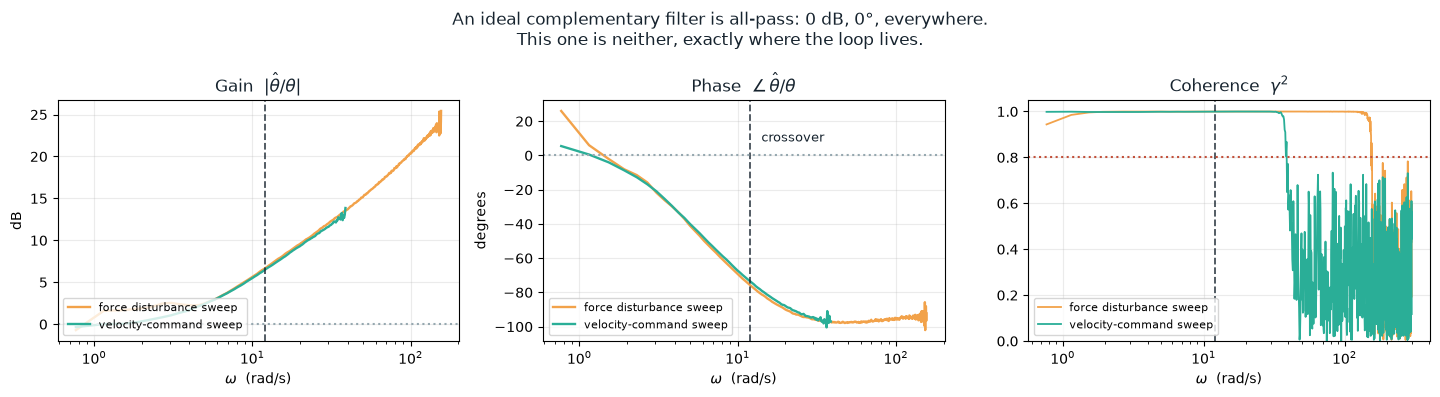

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(14.5, 4.0))
styles = {"force_sweep": (AMBER, "force disturbance sweep"),
          "vref_sweep":  (MINT,  "velocity-command sweep")}

for name, (colour, label) in styles.items():
    w = A[f"{name}_w"]
    H = A[f"{name}_H_real"] + 1j * A[f"{name}_H_imag"]
    coh = A[f"{name}_coh"]
    band = (w > 0.4) & (w < 300)
    ok = band & (coh > 0.8)          # only draw where the estimate means something
    ax[0].semilogx(w[ok], 20*np.log10(np.abs(H[ok])), color=colour, lw=1.7, label=label)
    ax[1].semilogx(w[ok], np.degrees(np.angle(H[ok])), color=colour, lw=1.7, label=label)
    ax[2].semilogx(w[band], coh[band], color=colour, lw=1.3, label=label)

for a, title, ylab in ((ax[0], r"Gain  $|\hat\theta/\theta|$", "dB"),
                       (ax[1], r"Phase  $\angle\,\hat\theta/\theta$", "degrees"),
                       (ax[2], r"Coherence  $\gamma^2$", "")):
    a.axvline(WC, ls="--", lw=1.3, color=INK, alpha=0.8)
    a.set_title(title, color=INK); a.set_xlabel(r"$\omega$  (rad/s)"); a.set_ylabel(ylab)
    a.legend(fontsize=8, loc="lower left")
ax[0].axhline(0, ls=":", color=MUTED); ax[1].axhline(0, ls=":", color=MUTED)
ax[2].axhline(0.8, ls=":", color=RED); ax[2].set_ylim(0, 1.05)
ax[1].annotate("crossover", (WC, 0), textcoords="offset points", xytext=(8, 10),
               fontsize=9, color=INK)
fig.suptitle(r"An ideal complementary filter is all-pass: 0 dB, 0°, everywhere."
             "\n" r"This one is neither, exactly where the loop lives.",
             color=INK, fontsize=12)
fig.tight_layout()

In [6]:
f, vv = fr["force_sweep"]["at_crossover"], fr["vref_sweep"]["at_crossover"]
print("At the crossover the two independent excitations agree:")
print(f"   force sweep    {f['gain_db']:+.2f} dB   {f['phase_deg']:+.1f}°")
print(f"   velocity sweep {vv['gain_db']:+.2f} dB   {vv['phase_deg']:+.1f}°")
print()
print("An ideal complementary filter would read 0 dB and 0°.")
print(f"Instead the estimate is AMPLIFIED by {10**(f['gain_db']/20):.2f}x and lags by ~{abs(f['phase_deg']):.0f}°")
print("at precisely the frequency the loop closes at. That is not a small error")
print("in the estimate -- it is a large, correlated distortion of the feedback signal.")

At the crossover the two independent excitations agree:
   force sweep    +6.60 dB   -75.5°
   velocity sweep +6.44 dB   -73.3°

An ideal complementary filter would read 0 dB and 0°.
Instead the estimate is AMPLIFIED by 2.14x and lags by ~76°
at precisely the frequency the loop closes at. That is not a small error
in the estimate -- it is a large, correlated distortion of the feedback signal.


---
## Debugging story 1 — the sweep that knocked the board over

The first version of this measurement drove the force chirp at 260 N and
produced a clean-looking Bode plot with **coherence 1.00** at crossover. The two
excitations disagreed sharply — $+15.5°$ against $-73.3°$ — and I wrote that up
as the finding: that $\hat\theta/\theta$ was not a well-defined transfer
function at all, and the error had to be a disturbance rather than a filter of
$\theta$. It was a satisfying conclusion. It was also wrong.

A 0.15 Hz chirp spends three seconds at a time shoving in one direction. At
260 N the board simply fell over partway through the sweep, the run terminated
early, and the analysis happily computed a transfer function from a truncated
record that ended in a crash. Shorter record → coarser frequency grid → the
"12 rad/s" bin was actually 15.7 rad/s; and the tail of the record was a fall
rather than a response.

**Coherence did not catch it.** $\gamma^2$ measures how linearly the output
follows the input, and a board falling over follows its input beautifully. The
guard that works is much dumber — *did the run stay upright?* — and the script
now refuses to report a sweep that struck:

```python
valid = {k: v for k, v in fr.items() if not v["struck"]}
```

Dropped to 35 N, both sweeps survive, and they agree to within 2 dB and 3°. The
lesson is not about chirps: it is that a validity check on the *experiment* has
to sit outside the statistics computed *from* it.

---
## Proving it: reproduce the defect on top of truth

A measured phase lag is a correlation, not yet a cause. The clean test is to
synthesise the *same defect* on top of a signal with no other error — feed the
loop **truth passed through a first-order lag** matched to the measured phase at
crossover,

$$\tau_{\text{lag}} = \frac{\tan|\phi(\omega_c)|}{\omega_c},$$

and separately **truth plus a constant offset** the size of the measured bias.
Whichever reproduces the crash is the mechanism.

In [7]:
d = P["discriminator"]
print(f"matched lag: tau = {d['lag_tau_s']*1000:.0f} ms\n")
print(f"{'what the P term was fed':<32}{'detail':<32}{'falls over':>11}{'peak':>9}")
for r in d["rows"]:
    print(f"{r['case']:<32}{r['detail']:<32}{'YES' if r['struck'] else 'no':>11}"
          f"{r['peak_abs_pitch_deg']:8.2f}°")

matched lag: tau = 322 ms

what the P term was fed         detail                           falls over     peak
truth (baseline)                -                                        no    7.62°
truth + matched lag             tau=322.3 ms (-75.5 deg at w_c)         YES   18.52°
truth + 10x lag                 tau=3222.7 ms                           YES   18.53°
truth + 1x measured offset      +0.111 deg constant                      no    7.62°
truth + 3x measured offset      +0.333 deg constant                      no    7.62°
the estimator itself            -                                       YES   18.52°


The verdict is unambiguous:

- **A constant offset does nothing.** Not at the measured size, not at three
  times it. The board does not care about a steady bias in its attitude
  estimate — the outer loop absorbs it. This kills the "it's drifting" theory.
- **The matched lag reproduces the crash exactly**, from truth, with no other
  error present at all.

So it is phase, and the amount of phase is the amount we measured. The estimate
being 0.66° from truth was never the problem; *when* it was 0.66° from truth
was.

Note the 10× lag row also crashes, but differently — at that time constant the
P term is nearly a constant and the loop is running on the D term alone. Two
distinct failures with one label, which is why the peak-pitch column is worth
reading next to the yes/no.

---
## The fix, and the trade it sits on

The residual $\varepsilon = (a - \hat a_{\text{fwd}})/g$ has two knobs.

**Lean on the accelerometer less.** LP$(s)$ scales the whole error term, so a
longer $\tau$ shrinks it at every frequency. The cost is the gyro bias term: a
constant bias $b$ leaves a steady error $b\tau$, so at the ICD's placeholder
0.002 rad/s, $\tau = 10$ s costs 1.15° of standing offset. Stability improves
and accuracy degrades, monotonically, in opposite directions.

**Or cancel the acceleration better.** The shipped aiding differentiates the
reported wheel speed — which arrives quantised at ~7 mrad/s and updated at
100 Hz — through a 50 ms dirty-derivative. That is a poor way to learn an
acceleration you *already know*, because you commanded it. The alternative is a
feedforward straight from the current just issued:

$$\hat a_{\text{fwd}} = \frac{k_t\,I}{r_{\text{eff}}\,m} \;\equiv\; K_{\text{ff}}\, I$$

with $K_{\text{ff}}$ a single constant to measure on the bench. No lag, no
quantisation. It is not strictly better — it is blind to anything it did not
cause, such as a slope, a kerb or wheel slip, which the odometry route does see.

In [8]:
rows = P["fix_sweep"]["rows"]
print(f"{'aiding':<9}{'tau':>6}{'falls over':>12}{'peak':>9}{'est RMS':>10}{'ends at':>10}")
last = None
for r in rows:
    if last and r["aiding"] != last:
        print()
    last = r["aiding"]
    rms = "  n/a" if r["est_rms_deg"] is None else f"{r['est_rms_deg']:.3f}°"
    print(f"{r['aiding']:<9}{r['tau_s']:6.1f}{'YES' if r['struck'] else 'no':>12}"
          f"{r['peak_abs_pitch_deg']:8.2f}°{rms:>10}{r['travel_m']:+9.3f}m")
b = P["fix_sweep"]["best"]
print(f"\nbest survivor: {b['aiding']} aiding, tau = {b['tau_s']} s"
      f"  ->  {b['est_rms_deg']:.3f}° RMS, finished {b['travel_m']:+.3f} m from home")

aiding      tau  falls over     peak   est RMS   ends at
wheel       1.0         YES   18.52°    2.066°   +0.009m
wheel       2.0         YES   18.56°    1.392°   +3.381m
wheel       5.0          no    9.36°    0.551°   +0.496m
wheel      10.0          no    8.55°    0.783°   +0.947m
wheel      20.0          no    8.13°    1.078°   +1.407m

torque      1.0         YES   18.53°    1.644°   +3.034m
torque      2.0          no    9.91°    0.491°   +0.021m
torque      5.0          no    8.55°    0.517°   +0.487m
torque     10.0          no    8.17°    0.777°   +0.940m
torque     20.0          no    7.95°    1.072°   +1.399m

none        1.0         YES   18.56°    1.720°   +0.103m
none        2.0         YES   18.52°    4.561°   +6.331m
none        5.0          no   11.73°    1.211°   +0.148m
none       10.0          no    8.18°    0.875°   +0.829m
none       20.0          no    7.88°    1.093°   +1.428m

best survivor: torque aiding, tau = 2.0 s  ->  0.491° RMS, finished +0.021 m from hom

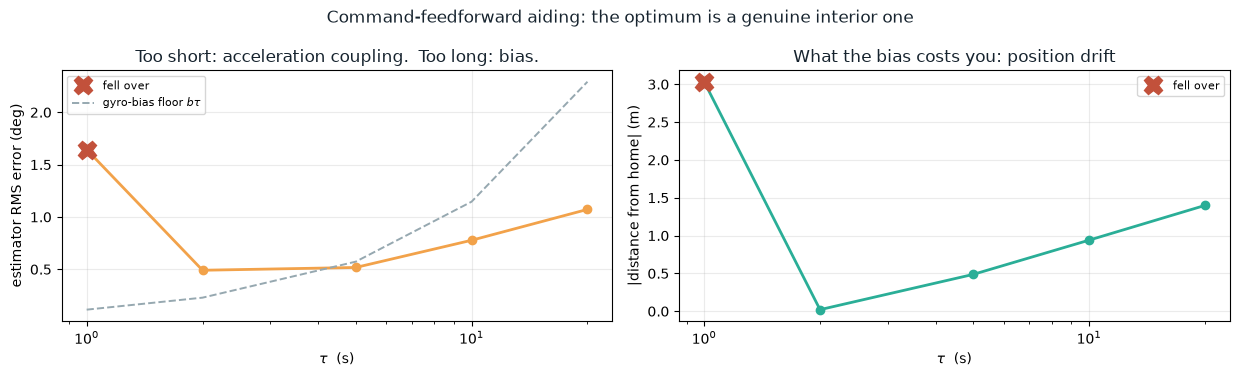

In [9]:
# The tau trade, drawn: acceleration coupling on one side, gyro bias on the other.
sub = [r for r in rows if r["aiding"] == "torque"]
tau = np.array([r["tau_s"] for r in sub])
rms = np.array([r["est_rms_deg"] for r in sub], dtype=float)
ret = np.array([abs(r["travel_m"]) for r in sub])
struck = np.array([r["struck"] for r in sub])

fig, ax = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax[0].semilogx(tau, rms, "o-", color=AMBER, lw=2)
ax[0].semilogx(tau[struck], rms[struck], "X", ms=13, color=RED, label="fell over")
ax[0].plot(tau, 0.002 * tau * 180 / np.pi, "--", color=MUTED, lw=1.4,
           label=r"gyro-bias floor $b\tau$")
ax[0].set_xlabel(r"$\tau$  (s)"); ax[0].set_ylabel("estimator RMS error (deg)")
ax[0].set_title("Too short: acceleration coupling.  Too long: bias.", color=INK)
ax[0].legend(fontsize=8)

ax[1].semilogx(tau, ret, "o-", color=MINT, lw=2)
ax[1].semilogx(tau[struck], ret[struck], "X", ms=13, color=RED, label="fell over")
ax[1].set_xlabel(r"$\tau$  (s)"); ax[1].set_ylabel("|distance from home| (m)")
ax[1].set_title("What the bias costs you: position drift", color=INK)
ax[1].legend(fontsize=8)
fig.suptitle("Command-feedforward aiding: the optimum is a genuine interior one",
             color=INK, fontsize=12)
fig.tight_layout()

### Verified end-to-end

The table above comes from the analysis harness. The numbers that matter were
re-measured through the **real** `shuttle_run` scenario driving the **real** Rust
controller over the FFI — no replica anywhere in the path:

| configuration | return error | falls over |
|---|---|---|
| estimator off (truth pitch) | 0.0648 m | no |
| wheel aiding, $\tau$ = 1 s *(the original)* | — | **yes** |
| wheel aiding, $\tau$ = 10 s | 0.9479 m | no |
| **command feedforward, $\tau$ = 2 s** | **0.0226 m** | **no** |

The board now completes the shuttle run on a fused attitude estimate and
finishes **closer to home than it does on perfect truth pitch** — 2.3 cm against
6.5 cm. That last part is a coincidence of this particular tuning rather than a
triumph, but it does mean the estimator is no longer the limiting factor on this
scenario.

---
## What is still broken

**The impulse scenario still fails with the estimator active**, and I have not
characterised it. Two measurements of the estimator's error under an impulse
disagree by an order of magnitude — 7.4° RMS through the scenario harness
against under 1° through a hand-rolled loop applying what should be the same
400 N disturbance. Until that is resolved I do not know which is right, and any
diagnosis of the impulse case would be a guess dressed as a result.

What is at least suggestive: on the impulse, *every* aiding source makes things
worse than no aiding at all (7.08° none, 7.44° feedforward, 7.80° odometry).
Both aiding routes assume acceleration comes from the motor. An external shove
breaks that assumption, and the feedforward confidently subtracts an
acceleration that is not happening.

An accelerometer genuinely cannot distinguish an external push from a tilt —
that is physics, not a bug. The standard mitigations are a **trust gate**
(reject the accelerometer when $\|a - \hat a_{\text{fwd}}\|$ is far from $g$),
which is implemented and only bought 1°; **lever-arm compensation** for the
$r\,\dot\omega$ term at the IMU; or a proper **error-state Kalman filter**, which
is what `control_core::Estimator` was made a trait for.

Open, and next.

---
## Further reading

The technique in this notebook is textbook classical control plus textbook
system identification. Good starting points:

**Frequency response, Bode plots, phase margin — why $-74°$ at crossover is
fatal**
- K. J. Åström & R. M. Murray, *Feedback Systems: An Introduction for Scientists
  and Engineers* — the standard modern text, free online at
  <https://fbswiki.org>. Chapters 9–10 (Frequency Domain Analysis, Loop
  Shaping) are exactly this material.
- Brian Douglas, *Control System Lectures* — <https://engineeringmedia.com>.
  The clearest intuitive treatment of Bode plots and phase margin available;
  start here if the algebra above went past you.

**Estimating a transfer function from measured data**
- J. S. Bendat & A. G. Piersol, *Random Data: Analysis and Measurement
  Procedures* — the reference for cross-spectra, Welch averaging and the
  coherence function.
- R. Pintelon & J. Schoukens, *System Identification: A Frequency Domain
  Approach* — rigorous treatment of swept-sine excitation and the bias
  properties of $\hat H = S_{xy}/S_{xx}$.
- SciPy's `signal.csd` / `signal.coherence`
  ([docs](https://docs.scipy.org/doc/scipy/reference/signal.html)) implement
  exactly what `welch_tf()` in `analyse_estimator_phase.py` does by hand — done
  by hand here only to keep the sim's dependency set small.

**Complementary and inertial attitude filters**
- W. T. Higgins, *A Comparison of Complementary and Kalman Filtering*, IEEE
  Trans. Aerospace & Electronic Systems, 1975 — the paper that showed a
  complementary filter is a steady-state Kalman filter, which is why the
  $\tau$ trade in this notebook has the shape it does.
- R. Mahony, T. Hamel & J.-M. Pflimlin, *Nonlinear Complementary Filters on the
  Special Orthogonal Group*, IEEE Trans. Automatic Control, 2008 — where to go
  for the full-attitude version.

**In this repo**
- `scripts/analyse_estimator_phase.py` — every number above.
- `crates/control-core/src/lib.rs` — `ComplementaryFilter`, `WheelAccelEstimator`
  and `CommandFeedforward`, with the trade documented at the definition.
- Notebook 3 for the accuracy story that precedes this one; notebook 2 for the
  cascade the estimator has to live inside.